# SVM — Heart Attack Prediction

Dataset: ~413 000 filas · target: `HadHeartAttack` · desbalance ~5.7 % positivos

## Decisiones de diseño

| Decisión | Justificación |
|---|---|
| `LinearSVC` | Con 400 k+ filas, `SVC(kernel='rbf')` construye una matriz de kernel de ~400k×400k que no cabe en RAM y tarda horas. `LinearSVC` escala linealmente. |
| `class_weight='balanced'` | Ajusta los pesos internamente según el desbalance 94/6 sin necesidad de sobremuestreo. |
| `CalibratedClassifierCV` | `LinearSVC` solo produce scores de decisión; la calibración Platt genera `predict_proba`, necesario para ROC-AUC y PR-AUC. |
| **Validación cruzada** | Outer 5-fold evalúa métricas sin sesgo; inner `GridSearchCV` 3-fold selecciona hiperparámetros. Estimación honesta del rendimiento real. |
| **Umbral F₂** | Maximiza F₂-score (β=2), que penaliza falsos negativos el doble que falsos positivos. Más apropiado que Youden en contexto clínico. |


## Métricas reportadas

- **PR-AUC** (Average Precision): métrica principal con clases desbalanceadas; no depende del umbral.
- **ROC-AUC**: discriminación global; complementa PR-AUC.
- **Brier Score**: calidad de calibración de probabilidades (↓ mejor).
- **F₂-score**: recall pesa el doble que precision → penaliza FN sobre FP.
- **Recall / Sensibilidad**: fracción de infartos reales detectados.
- **FN-rate** (miss-rate): 1 − recall; el costo clínico más alto.
- **Precision**: fracción de alarmas que son reales.


## 0. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, brier_score_loss,
    recall_score, precision_score, f1_score, fbeta_score,
    roc_curve, precision_recall_curve,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import time

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
TARGET = 'HadHeartAttack'


## 1. Carga del dataset




In [ ]:
# ─── AJUSTA ESTA RUTA ───────────────────────────────────────
df = pd.read_csv('dataset_features.csv')
# ────────────────────────────────────────────────────────────

print(f'Shape original: {df.shape}')
print(f'\nDistribución del target:')
print(df[TARGET].value_counts())
print(f'\n% positivos: {df[TARGET].mean()*100:.2f}%')


Shape original: (413460, 95)

Distribución del target:
HadHeartAttack
0    389886
1     23574
Name: count, dtype: int64

% positivos: 5.70%


## 2. Feature engineering específico para SVM


### Variables que se eliminan
| Columna | Razón |
|---|---|
| `HeightInMeters`, `WeightInKilograms` | Redundantes con BMI |
| `BMI` | Se reemplaza por `BMI_log` (distribución menos sesgada) |
| `HadAngina` | Leakage temporal: la angina es prácticamente diagnóstico previo de cardiopatía isquémica |


### Interacciones que se crean
Todas usan `(AgeCategory + 1)` para evitar el artefacto de cero cuando `AgeCategory=0`.

| Feature | Fórmula | Evidencia clínica |
|---|---|---|
| `BMI_x_Age` | `BMI_log × (AgeCategory+1)` | Obesidad + edad → riesgo CV multiplicado |
| `Smoker_x_Diabetes` | `SmokerStatus × HadDiabetes` | Efecto sinérgico, no aditivo (ADA 2023) |
| `BMI_x_Diabetes` | `BMI_log × HadDiabetes` | Resistencia a insulina + obesidad (Lancet 2009) |
| `Age_x_Diabetes` | `(AgeCategory+1) × HadDiabetes` | Diabéticos mayores: riesgo CV acumulado |
| `Smoker_x_Age` | `SmokerStatus × (AgeCategory+1)` | Fumadores mayores: daño vascular acumulado |


BMI_log creado ✓


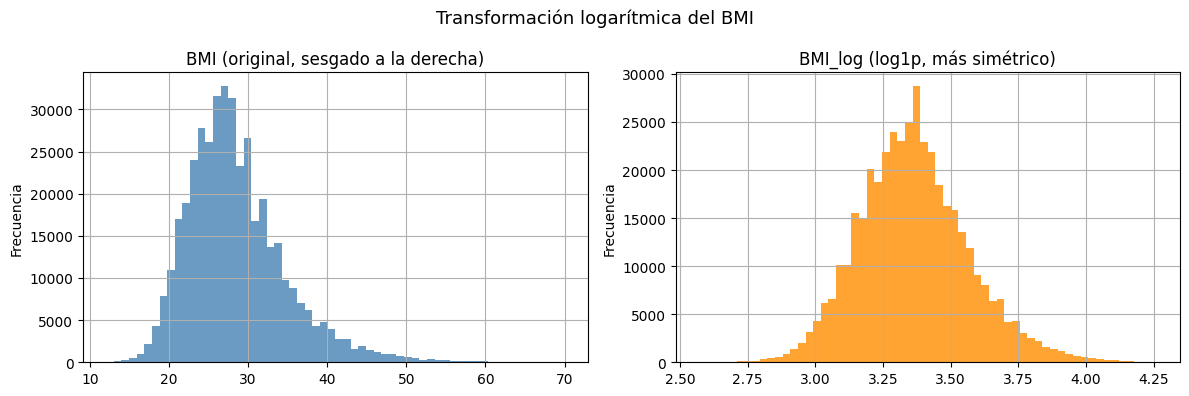

In [ ]:
df_svm = df.copy()

# ── 2.1  Crear BMI_log ────────────────────────────────────────────────────────
if 'BMI' in df_svm.columns:
    df_svm['BMI_log'] = np.log1p(df_svm['BMI'])
    print('BMI_log creado ✓')

# ── 2.2  Visualizar distribución BMI vs BMI_log ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_svm['BMI'].hist(bins=60, ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('BMI (original, sesgado a la derecha)')
axes[0].set_ylabel('Frecuencia')

df_svm['BMI_log'].hist(bins=60, ax=axes[1], color='darkorange', alpha=0.8)
axes[1].set_title('BMI_log (log1p, más simétrico)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Transformación logarítmica del BMI', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── 2.3  Eliminar columnas ────────────────────────────────────────────────────
COLS_DROP = [
    'HeightInMeters', 'WeightInKilograms',
    'BMI',                         # reemplazada por BMI_log
    'HadAngina',                   # leakage temporal
    'HadStroke',                   # leakage temporal
    'Angina_x_Diabetes',           # derivada de angina (si existiera)
    'Angina_x_Age',                # derivada de angina (si existiera)
    'BMI_x_Age',                   # si el CSV la tuviera con BMI original
]
COLS_DROP = [c for c in COLS_DROP if c in df_svm.columns]
df_svm = df_svm.drop(columns=COLS_DROP)

print(f'Columnas eliminadas ({len(COLS_DROP)}): {COLS_DROP}')
print(f'Shape tras eliminación: {df_svm.shape}')


Columnas eliminadas (5): ['HeightInMeters', 'WeightInKilograms', 'BMI', 'HadAngina', 'HadStroke']
Shape tras eliminación: (413460, 91)


In [ ]:
# ── 2.4  Crear features de interacción ───────────────────────────────────────

# 1. BMI × Edad  (obesidad + edad → riesgo multiplicado)
if 'BMI_log' in df_svm.columns and 'AgeCategory' in df_svm.columns:
    df_svm['BMI_x_Age'] = df_svm['BMI_log'] * (df_svm['AgeCategory'] + 1)
    print('BMI_x_Age creado ✓')

# 2. Tabaco × Diabetes  (efecto sinérgico — ADA Standards of Care 2023)
if 'SmokerStatus' in df_svm.columns and 'HadDiabetes' in df_svm.columns:
    df_svm['Smoker_x_Diabetes'] = df_svm['SmokerStatus'] * df_svm['HadDiabetes']
    print('Smoker_x_Diabetes creado ✓')

# 3. BMI × Diabetes  (resistencia a insulina + obesidad — Lancet 2009)
if 'BMI_log' in df_svm.columns and 'HadDiabetes' in df_svm.columns:
    df_svm['BMI_x_Diabetes'] = df_svm['BMI_log'] * df_svm['HadDiabetes']
    print('BMI_x_Diabetes creado ✓')

# 4. Edad × Diabetes  (diabéticos mayores: riesgo CV acumulado)
if 'AgeCategory' in df_svm.columns and 'HadDiabetes' in df_svm.columns:
    df_svm['Age_x_Diabetes'] = (df_svm['AgeCategory'] + 1) * df_svm['HadDiabetes']
    print('Age_x_Diabetes creado ✓')

# 5. Tabaco × Edad  (daño vascular acumulado en fumadores de mayor edad)
if 'SmokerStatus' in df_svm.columns and 'AgeCategory' in df_svm.columns:
    df_svm['Smoker_x_Age'] = df_svm['SmokerStatus'] * (df_svm['AgeCategory'] + 1)
    print('Smoker_x_Age creado ✓')

print(f'\nShape final: {df_svm.shape}')
print(f'Features de interacción: {[c for c in df_svm.columns if "_x_" in c]}')


BMI_x_Age creado ✓
Smoker_x_Diabetes creado ✓
BMI_x_Diabetes creado ✓
Age_x_Diabetes creado ✓
Smoker_x_Age creado ✓

Shape final: (413460, 96)
Features de interacción: ['BMI_x_Age', 'Smoker_x_Diabetes', 'BMI_x_Diabetes', 'Age_x_Diabetes', 'Smoker_x_Age']


In [ ]:
# ── 2.5  Verificación de nulos ────────────────────────────────────────────────
nulos = df_svm.isnull().sum()
nulos_presentes = nulos[nulos > 0]

if len(nulos_presentes) == 0:
    print('✅ Sin nulos en el dataset SVM.')
else:
    print(f'⚠️  Nulos en {len(nulos_presentes)} columnas → imputando con mediana')
    for col in nulos_presentes.index:
        df_svm[col] = df_svm[col].fillna(df_svm[col].median())
    print('✅ Imputación completada.')

print(f'\nDataset listo para modelar:')
print(f'  Filas:    {df_svm.shape[0]:,}')
print(f'  Features: {df_svm.shape[1]-1}')
print(f'  % pos:    {df_svm[TARGET].mean()*100:.2f}%')


✅ Sin nulos en el dataset SVM.

Dataset listo para modelar:
  Filas:    413,460
  Features: 95
  % pos:    5.70%


## 3. Separación de datos

Se reserva un **15% como holdout final** que no participa en absoluto en la búsqueda de
hiperparámetros ni en la validación cruzada.
El **85% restante** (pool de CV) es el universo sobre el que corre la CV.

```
Total (100%)
├── Holdout final (15%)       ← evaluación del modelo definitivo (solo al final)
└── Pool CV (85%)
    ├── Fold externo 1/5: train+val (68%) / test fold (17%)
    │   └── GridSearchCV sobre train+val: 3 inner folds × 4 C = 12 fits
    ├── Fold externo 2/5: ...
    ├── Fold externo 3/5: ...
    ├── Fold externo 4/5: ...
    └── Fold externo 5/5: ...
```


In [ ]:
X = df_svm.drop(columns=[TARGET])
y = df_svm[TARGET]

X_pool, X_holdout, y_pool, y_holdout = train_test_split(
    X, y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Pool CV:  {X_pool.shape[0]:,} filas  ({X_pool.shape[0]/len(X)*100:.0f}%)')
print(f'Holdout:  {X_holdout.shape[0]:,} filas ({X_holdout.shape[0]/len(X)*100:.0f}%)')
print(f'\n% positivos pool:    {y_pool.mean()*100:.2f}%')
print(f'% positivos holdout: {y_holdout.mean()*100:.2f}%')
print(f'\nFeatures totales: {X.shape[1]}')


Pool CV:  351,441 filas  (85%)
Holdout:  62,019 filas (15%)

% positivos pool:    5.70%
% positivos holdout: 5.70%

Features totales: 95


## 4. Pipeline

**Flujo:** `StandardScaler` → `LinearSVC` → `CalibratedClassifierCV` (Platt scaling)

Durante la búsqueda de hiperparámetros (`GridSearchCV` interno) se usa el pipeline **sin calibración**
para mayor velocidad — `LinearSVC` expone `decision_function`, que es suficiente para calcular
`average_precision` y `roc_auc` en scikit-learn.

La calibración Platt (`sigmoid`) se aplica solo al modelo final de cada fold externo y al modelo definitivo.


In [ ]:
def make_uncal_pipeline(C=1.0, random_state=RANDOM_STATE):
    """Pipeline sin calibrar → para GridSearchCV."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC(
            C=C,
            class_weight='balanced',
            max_iter=2000,
            random_state=random_state
        ))
    ])

def make_cal_pipeline(C=1.0, random_state=RANDOM_STATE):
    """Pipeline calibrado (Platt scaling) → genera predict_proba."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svm', CalibratedClassifierCV(
            LinearSVC(
                C=C,
                class_weight='balanced',
                max_iter=2000,
                random_state=random_state
            ),
            cv=3,
            method='sigmoid'
        ))
    ])

# Pipeline base para el GridSearch (sin calibrar)
pipeline_search = make_uncal_pipeline()

PARAM_GRID = {'svm__C': [0.01, 0.1, 1.0, 10.0]}

print('Pipeline de búsqueda (sin calibrar):')
print(pipeline_search)
print(f'\nGrid de hiperparámetros: {PARAM_GRID}')
print(f'\nFits por fold externo:')
print(f'  GridSearchCV: {len(PARAM_GRID["svm__C"])} valores C × 3 inner folds = {len(PARAM_GRID["svm__C"])*3} fits')
print(f'  Reentrenamiento calibrado: 1 modelo × 3 folds calibración = 3 fits')
print(f'\nTotal fits completos (5 folds externos):')
print(f'  {5 * (len(PARAM_GRID["svm__C"])*3 + 3)} LinearSVC fits')
print(f'\n⏱ Tiempo estimado: 1.5 - 3 horas (depende del hardware)')


Pipeline de búsqueda (sin calibrar):
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 LinearSVC(class_weight='balanced', max_iter=2000,
                           random_state=42))])

Grid de hiperparámetros: {'svm__C': [0.01, 0.1, 1.0, 10.0]}

Fits por fold externo:
  GridSearchCV: 4 valores C × 3 inner folds = 12 fits
  Reentrenamiento calibrado: 1 modelo × 3 folds calibración = 3 fits

Total fits completos (5 folds externos):
  75 LinearSVC fits

⏱ Tiempo estimado: 1.5 - 3 horas (depende del hardware)


## 5. Validación cruzada anidada


### Métrica de selección interna
Se usa **`average_precision`** (PR-AUC) como criterio del GridSearchCV interno.
Es threshold-independent y captura el trade-off precision/recall, alineado con el objetivo clínico.

### Métricas reportadas por fold

| Métrica | Tipo | Relevancia clínica |
|---|---|---|
| PR-AUC | Threshold-free | Alta — principal con desbalance |
| ROC-AUC | Threshold-free | Alta — discriminación global |
| Brier Score | Threshold-free | Media — calibración de probabilidades |
| Recall @ F₂ | Threshold-dep. | Alta — infartos detectados |
| FN-rate @ F₂ | Threshold-dep. | Alta — costo clínico crítico |
| F₂-score @ F₂ | Threshold-dep. | Alta — balance penalizando FN×2 |
| Recall @ 0.30 | Threshold-dep. | Referencia fija entre modelos |


## 6. Ejecución del CV


In [ ]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

nested_results = []
t_total = time.time()

for fold_idx, (cv_idx, test_idx) in enumerate(outer_cv.split(X_pool, y_pool)):

    t_fold = time.time()
    print(f'\n{"="*65}')
    print(f'  FOLD EXTERNO {fold_idx+1}/5')
    print(f'{"="*65}')

    X_cv_fold   = X_pool.iloc[cv_idx]
    y_cv_fold   = y_pool.iloc[cv_idx]
    X_test_fold = X_pool.iloc[test_idx]
    y_test_fold = y_pool.iloc[test_idx]

    print(f'  Train+Val: {len(X_cv_fold):,} | Test fold: {len(X_test_fold):,}')
    print(f'  % pos. train: {y_cv_fold.mean()*100:.2f}%  |  % pos. test: {y_test_fold.mean()*100:.2f}%')

    # ── [1/2] Inner GridSearchCV: encontrar mejor C ────────────────────────
    t_grid = time.time()
    print(f'  [1/2] GridSearchCV ({len(PARAM_GRID["svm__C"])} C × 3 inner folds, scoring=average_precision)...')

    grid = GridSearchCV(
        make_uncal_pipeline(),
        PARAM_GRID,
        cv=inner_cv,
        scoring='average_precision',
        n_jobs=-1,
        verbose=0,
        refit=False
    )
    grid.fit(X_cv_fold, y_cv_fold)

    best_C            = grid.best_params_['svm__C']
    best_inner_pr_auc = grid.best_score_

    print(f'       Mejor C = {best_C}  |  PR-AUC val. interno = {best_inner_pr_auc:.4f}')
    print(f'       Tiempo grid: {(time.time()-t_grid)/60:.1f} min')

    # ── [2/2] Reentrenar con mejor C + calibración Platt ──────────────────
    t_cal = time.time()
    print(f'  [2/2] Reentrenando con C={best_C} + calibración Platt (cv=3)...')

    cal_pipeline = make_cal_pipeline(best_C)
    cal_pipeline.fit(X_cv_fold, y_cv_fold)

    print(f'       Tiempo calibración: {(time.time()-t_cal)/60:.1f} min')

    # ── Evaluación en test fold ────────────────────────────────────────────
    y_proba_fold = cal_pipeline.predict_proba(X_test_fold)[:, 1]

    roc_auc_fold = roc_auc_score(y_test_fold, y_proba_fold)
    pr_auc_fold  = average_precision_score(y_test_fold, y_proba_fold)
    brier_fold   = brier_score_loss(y_test_fold, y_proba_fold)

    # Umbral F2-óptimo en este fold
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test_fold, y_proba_fold)
    denom = 4 * prec_arr + rec_arr
    f2_arr = np.where(denom > 0, 5 * prec_arr * rec_arr / denom, 0.0)
    best_idx    = np.argmax(f2_arr[:-1])
    best_thresh = thresh_arr[best_idx]

    y_pred_f2 = (y_proba_fold >= best_thresh).astype(int)
    y_pred_03 = (y_proba_fold >= 0.30).astype(int)

    rec_f2  = recall_score(y_test_fold, y_pred_f2)
    prec_f2 = precision_score(y_test_fold, y_pred_f2, zero_division=0)
    f2_f2   = fbeta_score(y_test_fold, y_pred_f2, beta=2)

    rec_03  = recall_score(y_test_fold, y_pred_03)
    prec_03 = precision_score(y_test_fold, y_pred_03, zero_division=0)
    f2_03   = fbeta_score(y_test_fold, y_pred_03, beta=2)

    elapsed_fold = (time.time() - t_fold) / 60

    result = {
        'fold':         fold_idx + 1,
        'best_C':       best_C,
        'inner_pr_auc': best_inner_pr_auc,
        'roc_auc':      roc_auc_fold,
        'pr_auc':       pr_auc_fold,
        'brier':        brier_fold,
        'threshold_f2': best_thresh,
        'recall_f2':    rec_f2,
        'precision_f2': prec_f2,
        'f2_score_f2':  f2_f2,
        'fn_rate_f2':   1 - rec_f2,
        'recall_03':    rec_03,
        'precision_03': prec_03,
        'f2_score_03':  f2_03,
        'fn_rate_03':   1 - rec_03,
        'elapsed_min':  elapsed_fold,
    }
    nested_results.append(result)

    print(f'\n  ✅ Fold {fold_idx+1} — {elapsed_fold:.1f} min')
    print(f'     ROC-AUC={roc_auc_fold:.4f}  |  PR-AUC={pr_auc_fold:.4f}  |  Brier={brier_fold:.4f}')
    print(f'     [F₂-thr={best_thresh:.3f}] Recall={rec_f2:.4f}  |  F₂={f2_f2:.4f}  |  FN-rate={1-rec_f2:.4f}')

total_time = (time.time() - t_total) / 60
print(f'\n{"="*65}')
print(f'  NESTED CV COMPLETADA — Tiempo total: {total_time:.1f} min')
print(f'{"="*65}')



  FOLD EXTERNO 1/5
  Train+Val: 281,152 | Test fold: 70,289
  % pos. train: 5.70%  |  % pos. test: 5.70%
  [1/2] GridSearchCV (4 C × 3 inner folds, scoring=average_precision)...
       Mejor C = 0.1  |  PR-AUC val. interno = 0.2399
       Tiempo grid: 1.4 min
  [2/2] Reentrenando con C=0.1 + calibración Platt (cv=3)...
       Tiempo calibración: 0.4 min

  ✅ Fold 1 — 1.8 min
     ROC-AUC=0.8342  |  PR-AUC=0.2378  |  Brier=0.0480
     [F₂-thr=0.075] Recall=0.7021  |  F₂=0.4349  |  FN-rate=0.2979

  FOLD EXTERNO 2/5
  Train+Val: 281,153 | Test fold: 70,288
  % pos. train: 5.70%  |  % pos. test: 5.70%
  [1/2] GridSearchCV (4 C × 3 inner folds, scoring=average_precision)...
       Mejor C = 0.01  |  PR-AUC val. interno = 0.2392
       Tiempo grid: 1.4 min
  [2/2] Reentrenando con C=0.01 + calibración Platt (cv=3)...
       Tiempo calibración: 0.5 min

  ✅ Fold 2 — 1.9 min
     ROC-AUC=0.8397  |  PR-AUC=0.2430  |  Brier=0.0478
     [F₂-thr=0.079] Recall=0.6930  |  F₂=0.4421  |  FN-rate=0.3

## 7. Resultados por fold

In [ ]:
results_df = pd.DataFrame(nested_results)

print('='*75)
print('MÉTRICAS POR FOLD — Threshold-free')
print('='*75)
print(results_df[['fold', 'best_C', 'roc_auc', 'pr_auc', 'brier', 'inner_pr_auc']].to_string(index=False))

print()
print('='*75)
print('MÉTRICAS POR FOLD — Umbral F₂-óptimo')
print('='*75)
print(results_df[['fold', 'threshold_f2', 'recall_f2', 'precision_f2', 'f2_score_f2', 'fn_rate_f2']].to_string(index=False))

print()
print('='*75)
print('MÉTRICAS POR FOLD — Umbral fijo 0.30')
print('='*75)
print(results_df[['fold', 'recall_03', 'precision_03', 'f2_score_03', 'fn_rate_03']].to_string(index=False))

print()
print('='*75)
print('RESUMEN ESTADÍSTICO (media ± desv. estándar) — estimaciones no sesgadas')
print('='*75)
metric_cols = ['roc_auc', 'pr_auc', 'brier',
               'recall_f2', 'precision_f2', 'f2_score_f2', 'fn_rate_f2',
               'recall_03', 'f2_score_03', 'fn_rate_03']
summary = results_df[metric_cols].agg(['mean', 'std'])
print(summary.round(4).to_string())


MÉTRICAS POR FOLD — Threshold-free
 fold  best_C  roc_auc  pr_auc  brier  inner_pr_auc
    1  0.1000   0.8342  0.2378 0.0480        0.2399
    2  0.0100   0.8397  0.2430 0.0478        0.2392
    3  0.0100   0.8400  0.2387 0.0479        0.2399
    4  0.0100   0.8399  0.2444 0.0478        0.2384
    5  0.0100   0.8351  0.2375 0.0480        0.2406

MÉTRICAS POR FOLD — Umbral F₂-óptimo
 fold  threshold_f2  recall_f2  precision_f2  f2_score_f2  fn_rate_f2
    1        0.0753     0.7021        0.1725       0.4349      0.2979
    2        0.0794     0.6930        0.1805       0.4421      0.3070
    3        0.0792     0.6985        0.1778       0.4406      0.3015
    4        0.0724     0.7295        0.1732       0.4442      0.2705
    5        0.0844     0.6694        0.1832       0.4373      0.3306

MÉTRICAS POR FOLD — Umbral fijo 0.30
 fold  recall_03  precision_03  f2_score_03  fn_rate_03
    1     0.1572        0.3452       0.1764      0.8428
    2     0.1547        0.3580       0.1745  

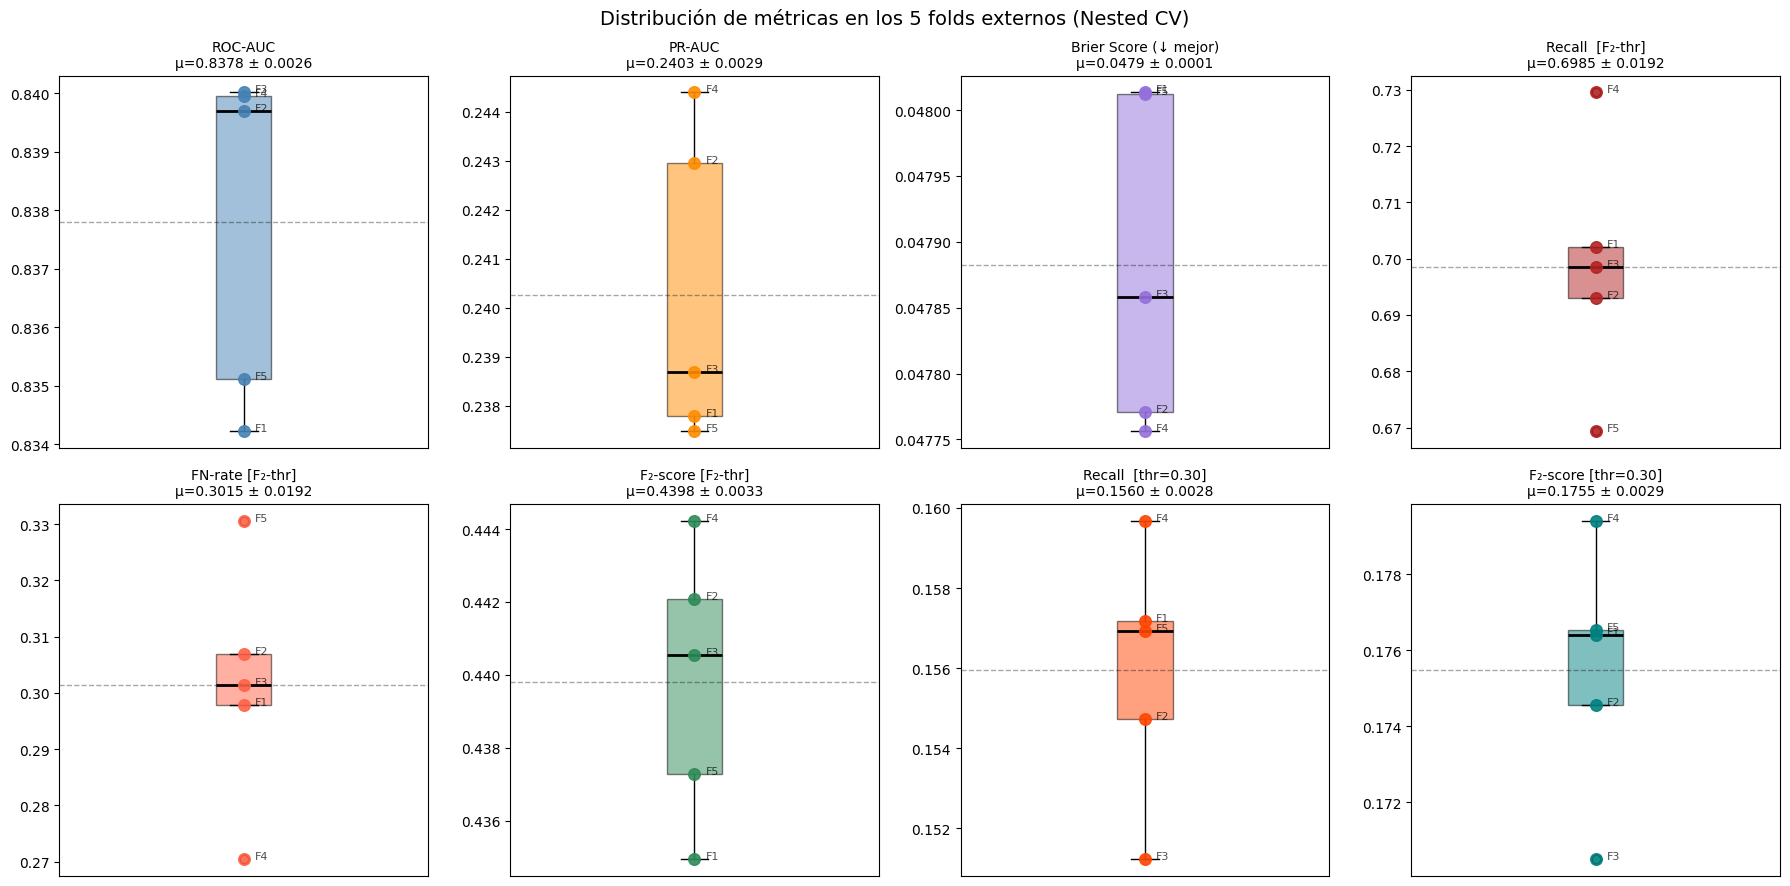

In [ ]:
# ── Boxplots de métricas principales ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Distribución de métricas en los 5 folds externos (Nested CV)', fontsize=14)

metrics_plot = [
    ('roc_auc',      'ROC-AUC',              'steelblue'),
    ('pr_auc',       'PR-AUC',               'darkorange'),
    ('brier',        'Brier Score (↓ mejor)', 'mediumpurple'),
    ('recall_f2',    'Recall  [F₂-thr]',     'firebrick'),
    ('fn_rate_f2',   'FN-rate [F₂-thr]',     'tomato'),
    ('f2_score_f2',  'F₂-score [F₂-thr]',    'seagreen'),
    ('recall_03',    'Recall  [thr=0.30]',    'orangered'),
    ('f2_score_03',  'F₂-score [thr=0.30]',  'teal'),
]

for ax, (col, label, color) in zip(axes.flat, metrics_plot):
    values = results_df[col].values
    ax.boxplot(values, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='black', linewidth=2))
    for i, v in enumerate(values):
        ax.scatter(1, v, color=color, zorder=5, s=70, alpha=0.9)
        ax.annotate(f'F{i+1}', (1, v), textcoords='offset points',
                    xytext=(8, 0), fontsize=8, alpha=0.7)
    mean_v = np.mean(values)
    ax.axhline(mean_v, color='black', linestyle='--', alpha=0.35, linewidth=1)
    ax.set_title(f'{label}\nμ={mean_v:.4f} ± {np.std(values):.4f}', fontsize=10)
    ax.set_xticks([])
    ax.set_xlim(0.5, 1.5)

plt.tight_layout()
plt.show()


## 8. Análisis de hiperparámetros seleccionados por fold

Valor de C seleccionado por cada fold externo:
 fold  best_C  inner_pr_auc  pr_auc  roc_auc
    1  0.1000        0.2399  0.2378   0.8342
    2  0.0100        0.2392  0.2430   0.8397
    3  0.0100        0.2399  0.2387   0.8400
    4  0.0100        0.2384  0.2444   0.8399
    5  0.0100        0.2406  0.2375   0.8351

Frecuencia de cada C:
best_C
0.0100    4
0.1000    1

→ C de consenso (moda): 0.01
  Este valor se usa para entrenar el modelo final.


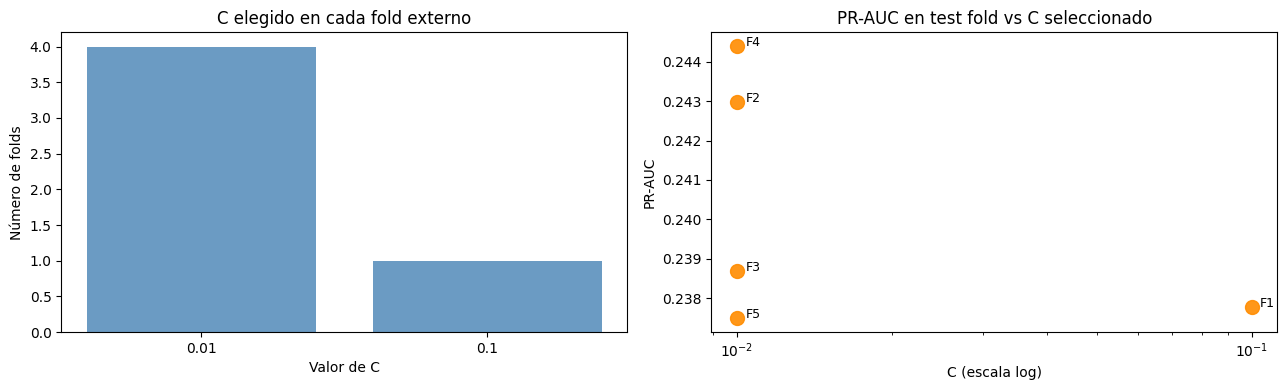

In [ ]:
print('Valor de C seleccionado por cada fold externo:')
print(results_df[['fold', 'best_C', 'inner_pr_auc', 'pr_auc', 'roc_auc']].to_string(index=False))

c_counts = results_df['best_C'].value_counts().sort_index()
print(f'\nFrecuencia de cada C:')
print(c_counts.to_string())

C_consensus = results_df['best_C'].mode()[0]
print(f'\n→ C de consenso (moda): {C_consensus}')
print(f'  Este valor se usa para entrenar el modelo final.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(c_counts.index.astype(str), c_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('C elegido en cada fold externo')
axes[0].set_xlabel('Valor de C')
axes[0].set_ylabel('Número de folds')

axes[1].scatter(results_df['best_C'], results_df['pr_auc'],
                s=100, c='darkorange', zorder=5, alpha=0.9)
for _, row in results_df.iterrows():
    axes[1].annotate(f"F{int(row['fold'])}", (row['best_C'], row['pr_auc']),
                     textcoords='offset points', xytext=(6, 0), fontsize=9)
axes[1].set_xscale('log')
axes[1].set_title('PR-AUC en test fold vs C seleccionado')
axes[1].set_xlabel('C (escala log)')
axes[1].set_ylabel('PR-AUC')

plt.tight_layout()
plt.show()


## 9. Modelo final

Con el `C` de consenso se entrena el modelo definitivo sobre el **pool completo (85%)** y se evalúa
sobre el **holdout final (15%)** que nunca participó en ninguna decisión.

Este resultado es la estimación de producción más honesta disponible.


In [ ]:
print(f'Entrenando modelo final con C={C_consensus} sobre {len(X_pool):,} filas...')
t0 = time.time()

final_model = make_cal_pipeline(C_consensus)
final_model.fit(X_pool, y_pool)

elapsed = (time.time() - t0) / 60
print(f'✅ Entrenamiento completado en {elapsed:.1f} min')


Entrenando modelo final con C=0.01 sobre 351,441 filas...
✅ Entrenamiento completado en 0.5 min


In [ ]:
y_proba_holdout = final_model.predict_proba(X_holdout)[:, 1]

roc_auc_final = roc_auc_score(y_holdout, y_proba_holdout)
pr_auc_final  = average_precision_score(y_holdout, y_proba_holdout)
brier_final   = brier_score_loss(y_holdout, y_proba_holdout)

print('='*65)
print('MÉTRICAS EN HOLDOUT FINAL (threshold-free)')
print('='*65)
print(f'ROC-AUC:     {roc_auc_final:.4f}   (CV media: {results_df["roc_auc"].mean():.4f})')
print(f'PR-AUC:      {pr_auc_final:.4f}   (CV media: {results_df["pr_auc"].mean():.4f})')
print(f'Brier Score: {brier_final:.4f}   (CV media: {results_df["brier"].mean():.4f})')
print(f'Baseline PR (random): {y_holdout.mean():.4f}')


MÉTRICAS EN HOLDOUT FINAL (threshold-free)
ROC-AUC:     0.8349   (CV media: 0.8378)
PR-AUC:      0.2352   (CV media: 0.2403)
Brier Score: 0.0481   (CV media: 0.0479)
Baseline PR (random): 0.0570


## 10. Selección del umbral óptimo

Se comparan tres estrategias de umbral sobre el holdout final:

| Umbral | Criterio | Contexto |
|---|---|---|
| **F₂-óptimo** | Maximiza F₂ (β=2): penaliza FN el doble que FP | Recomendado para uso clínico |
| **Youden** | Maximiza sensibilidad + especificidad − 1 | Clásico de medicina diagnóstica |
| **0.30** | Fijo | Referencia para comparar modelos entre sí |


In [ ]:
# ── Umbral F₂-óptimo ─────────────────────────────────────────────────────────
prec_h, rec_h, thresh_h = precision_recall_curve(y_holdout, y_proba_holdout)
denom_h = 4 * prec_h + rec_h
f2_h    = np.where(denom_h > 0, 5 * prec_h * rec_h / denom_h, 0.0)
best_idx_h   = np.argmax(f2_h[:-1])
threshold_f2 = thresh_h[best_idx_h]

# ── Umbral Youden ─────────────────────────────────────────────────────────────
fpr_h, tpr_h, roc_thresholds = roc_curve(y_holdout, y_proba_holdout)
youden_idx        = np.argmax(tpr_h - fpr_h)
threshold_youden  = roc_thresholds[youden_idx]

print(f'Umbral F₂-óptimo: {threshold_f2:.4f}')
print(f'Umbral Youden:    {threshold_youden:.4f}')
print(f'Umbral fijo:      0.3000')
print()

y_pred_f2     = (y_proba_holdout >= threshold_f2).astype(int)
y_pred_youden = (y_proba_holdout >= threshold_youden).astype(int)
y_pred_03     = (y_proba_holdout >= 0.30).astype(int)

print('='*72)
print('COMPARATIVA DE UMBRALES EN HOLDOUT FINAL')
print('='*72)
print(f'  {"Umbral":<22} {"Recall":>7} {"FN-rate":>8} {"F₂":>7} {"Precision":>10} {"F1":>7}')
print('-'*72)

for nombre, y_pred, thr in [
    ('F₂-óptimo',  y_pred_f2,     threshold_f2),
    ('Youden',     y_pred_youden, threshold_youden),
    ('Fijo 0.30',  y_pred_03,     0.30),
]:
    rec  = recall_score(y_holdout, y_pred)
    prec = precision_score(y_holdout, y_pred, zero_division=0)
    f2v  = fbeta_score(y_holdout, y_pred, beta=2)
    f1v  = f1_score(y_holdout, y_pred, zero_division=0)
    print(f'  {nombre:<22} {rec:>7.4f} {1-rec:>8.4f} {f2v:>7.4f} {prec:>10.4f} {f1v:>7.4f}  (thr={thr:.3f})')


Umbral F₂-óptimo: 0.0736
Umbral Youden:    0.0467
Umbral fijo:      0.3000

COMPARATIVA DE UMBRALES EN HOLDOUT FINAL
  Umbral                  Recall  FN-rate      F₂  Precision      F1
------------------------------------------------------------------------
  F₂-óptimo               0.7073   0.2927  0.4353     0.1715  0.2760  (thr=0.074)
  Youden                  0.8337   0.1663  0.4200     0.1407  0.2408  (thr=0.047)
  Fijo 0.30               0.1606   0.8394  0.1805     0.3575  0.2217  (thr=0.300)


In [ ]:
print('\n--- Classification Report — Umbral F₂-óptimo ---')
print(classification_report(y_holdout, y_pred_f2, target_names=['No HA', 'HeartAttack']))

print('\n--- Classification Report — Umbral Youden ---')
print(classification_report(y_holdout, y_pred_youden, target_names=['No HA', 'HeartAttack']))

print('\n--- Classification Report — Umbral 0.30 ---')
print(classification_report(y_holdout, y_pred_03, target_names=['No HA', 'HeartAttack']))



--- Classification Report — Umbral F₂-óptimo ---
              precision    recall  f1-score   support

       No HA       0.98      0.79      0.88     58483
 HeartAttack       0.17      0.71      0.28      3536

    accuracy                           0.79     62019
   macro avg       0.57      0.75      0.58     62019
weighted avg       0.93      0.79      0.84     62019


--- Classification Report — Umbral Youden ---
              precision    recall  f1-score   support

       No HA       0.99      0.69      0.81     58483
 HeartAttack       0.14      0.83      0.24      3536

    accuracy                           0.70     62019
   macro avg       0.56      0.76      0.53     62019
weighted avg       0.94      0.70      0.78     62019


--- Classification Report — Umbral 0.30 ---
              precision    recall  f1-score   support

       No HA       0.95      0.98      0.97     58483
 HeartAttack       0.36      0.16      0.22      3536

    accuracy                           0

## 11. Curvas ROC y Precision-Recall

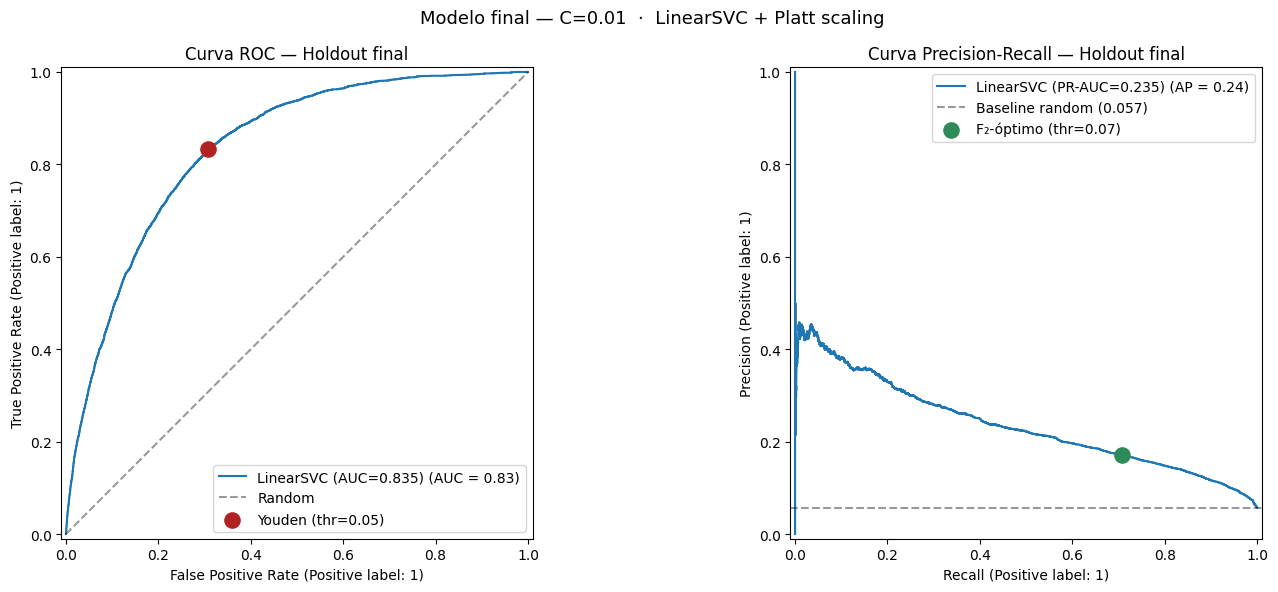


PR-AUC baseline (random): 0.0570
PR-AUC del modelo:         0.2352  →  4.1× sobre el baseline


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── ROC ───────────────────────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(
    y_holdout, y_proba_holdout, ax=axes[0],
    name=f'LinearSVC (AUC={roc_auc_final:.3f})'
)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].scatter(fpr_h[youden_idx], tpr_h[youden_idx],
                s=120, color='firebrick', zorder=6,
                label=f'Youden (thr={threshold_youden:.2f})')
axes[0].set_title('Curva ROC — Holdout final')
axes[0].legend()

# ── Precision-Recall ──────────────────────────────────────────────────────────
PrecisionRecallDisplay.from_predictions(
    y_holdout, y_proba_holdout, ax=axes[1],
    name=f'LinearSVC (PR-AUC={pr_auc_final:.3f})'
)
baseline = y_holdout.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', alpha=0.4,
                label=f'Baseline random ({baseline:.3f})')
axes[1].scatter(rec_h[best_idx_h], prec_h[best_idx_h],
                s=120, color='seagreen', zorder=6,
                label=f'F₂-óptimo (thr={threshold_f2:.2f})')
axes[1].set_title('Curva Precision-Recall — Holdout final')
axes[1].legend()

plt.suptitle(f'Modelo final — C={C_consensus}  ·  LinearSVC + Platt scaling', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nPR-AUC baseline (random): {baseline:.4f}')
print(f'PR-AUC del modelo:         {pr_auc_final:.4f}  →  {pr_auc_final/baseline:.1f}× sobre el baseline')


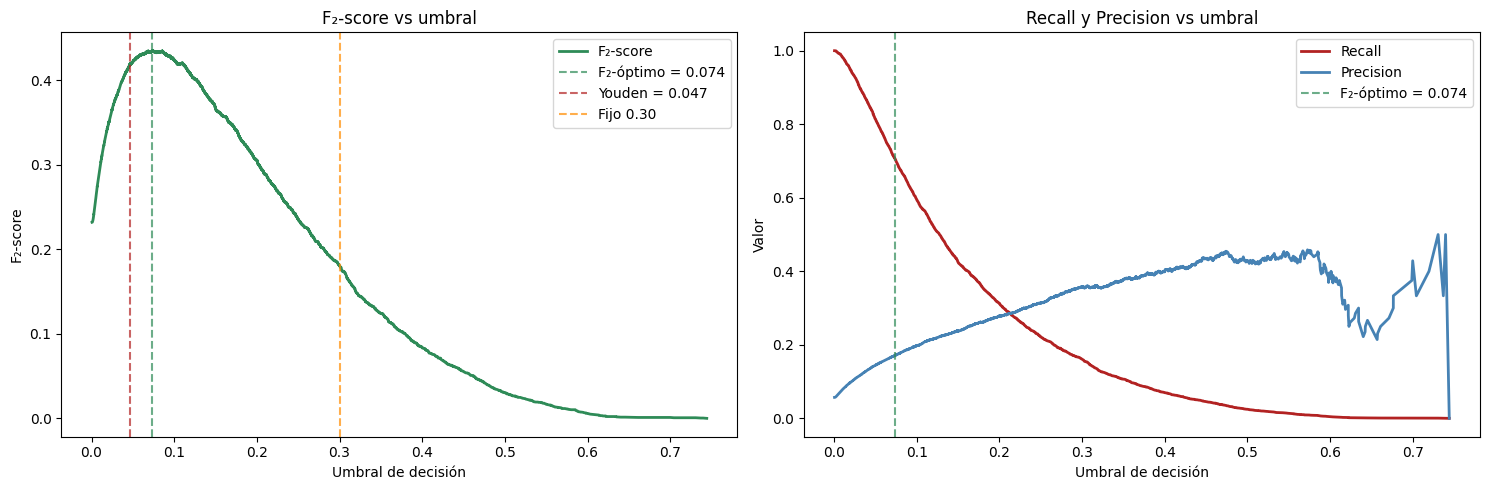

In [ ]:
# ── F₂-score, Recall y Precision en función del umbral ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(thresh_h, f2_h[:-1], color='seagreen', linewidth=2, label='F₂-score')
axes[0].axvline(threshold_f2, color='seagreen', linestyle='--', alpha=0.7,
                label=f'F₂-óptimo = {threshold_f2:.3f}')
axes[0].axvline(threshold_youden, color='firebrick', linestyle='--', alpha=0.7,
                label=f'Youden = {threshold_youden:.3f}')
axes[0].axvline(0.30, color='darkorange', linestyle='--', alpha=0.7, label='Fijo 0.30')
axes[0].set_xlabel('Umbral de decisión')
axes[0].set_ylabel('F₂-score')
axes[0].set_title('F₂-score vs umbral')
axes[0].legend()

axes[1].plot(thresh_h, rec_h[:-1],  color='firebrick', linewidth=2, label='Recall')
axes[1].plot(thresh_h, prec_h[:-1], color='steelblue', linewidth=2, label='Precision')
axes[1].axvline(threshold_f2, color='seagreen', linestyle='--', alpha=0.7,
                label=f'F₂-óptimo = {threshold_f2:.3f}')
axes[1].set_xlabel('Umbral de decisión')
axes[1].set_ylabel('Valor')
axes[1].set_title('Recall y Precision vs umbral')
axes[1].legend()

plt.tight_layout()
plt.show()


## 12. Matrices de confusión

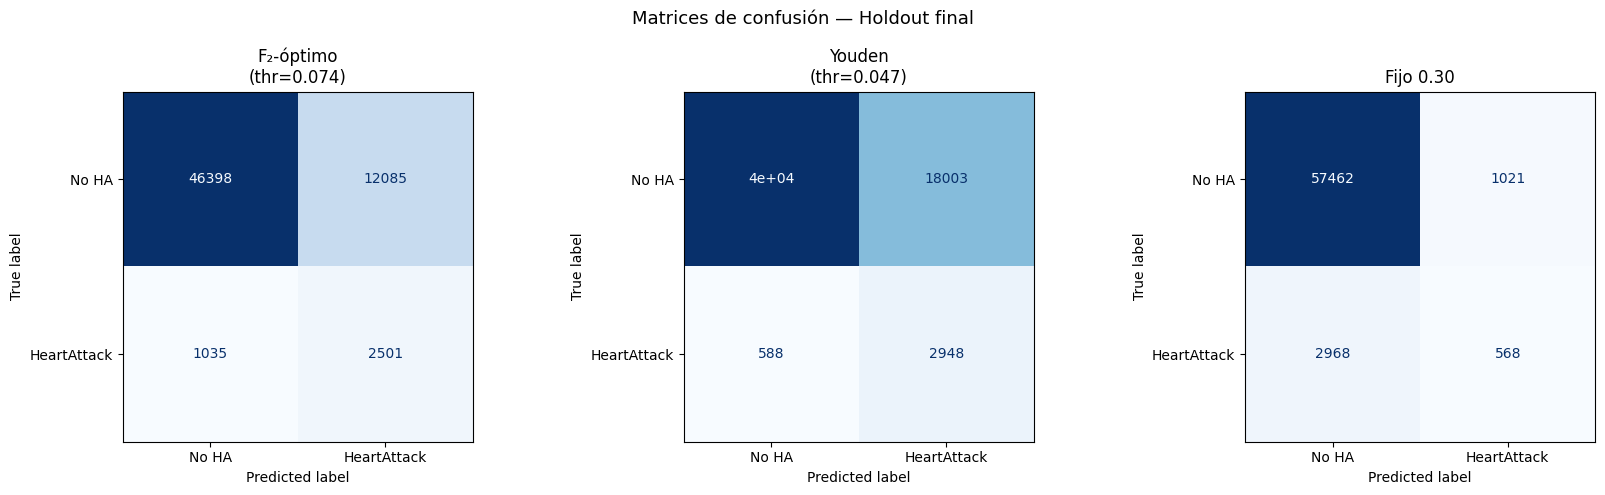


── Interpretación clínica — umbral F₂-óptimo ──────────────────────────
Total en holdout:                     62,019
✅  Dijo NO  → realmente NO:           46,398   (verdaderos negativos)
✅  Dijo SÍ  → realmente SÍ:           2,501   (verdaderos positivos)
⚠️   Dijo SÍ  → realmente NO:           12,085   (falsas alarmas)
🚨  Dijo NO  → realmente SÍ:            1,035   (FN — los críticos)

De 3,536 pacientes que SÍ tuvieron infarto,
el modelo no detectó a 1,035 (29.3%).


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Matrices de confusión — Holdout final', fontsize=13)

for ax, (nombre, y_pred, thr) in zip(axes, [
    (f'F₂-óptimo\n(thr={threshold_f2:.3f})',    y_pred_f2,     threshold_f2),
    (f'Youden\n(thr={threshold_youden:.3f})',    y_pred_youden, threshold_youden),
    ('Fijo 0.30',                                 y_pred_03,     0.30),
]):
    cm = confusion_matrix(y_holdout, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No HA', 'HeartAttack'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

# ── Interpretación clínica (umbral F₂-óptimo) ────────────────────────────────
print('\n── Interpretación clínica — umbral F₂-óptimo ──────────────────────────')
TN, FP, FN, TP = confusion_matrix(y_holdout, y_pred_f2).ravel()
n_pos = int(y_holdout.sum())

print(f'Total en holdout:                     {len(y_holdout):,}')
print(f'✅  Dijo NO  → realmente NO:           {TN:,}   (verdaderos negativos)')
print(f'✅  Dijo SÍ  → realmente SÍ:           {TP:,}   (verdaderos positivos)')
print(f'⚠️   Dijo SÍ  → realmente NO:           {FP:,}   (falsas alarmas)')
print(f'🚨  Dijo NO  → realmente SÍ:            {FN:,}   (FN — los críticos)')
print()
print(f'De {n_pos:,} pacientes que SÍ tuvieron infarto,')
print(f'el modelo no detectó a {FN:,} ({FN/n_pos*100:.1f}%).')


## 13. Importancia de features (Permutation Importance)

`LinearSVC` no expone `feature_importances_` como los árboles.
La **Permutation Importance** mide la caída en ROC-AUC al permutar aleatoriamente cada variable:
si permutar una columna empeora mucho el modelo, esa variable aporta información real.

Se calcula sobre una muestra del holdout para acelerar (n=12 000, 10 repeticiones).


Calculando permutation importance sobre 30,000 muestras (10 repeticiones)...
✅ Completado en 0.8 min


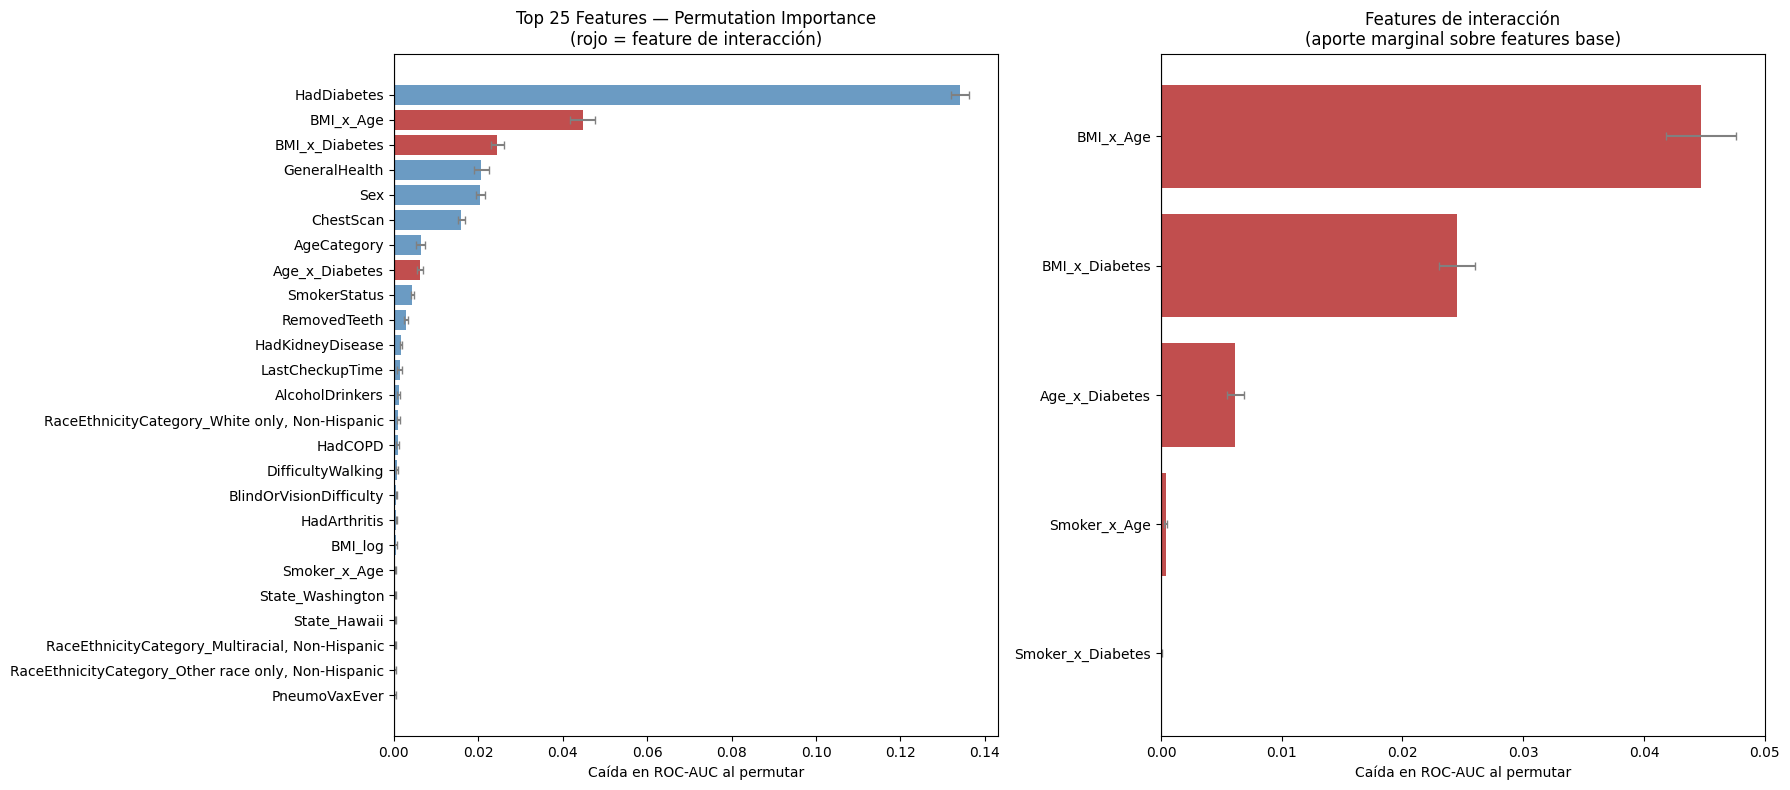


Top 15 features:
                                       feature  importance_mean  importance_std
                                   HadDiabetes           0.1341          0.0021
                                     BMI_x_Age           0.0447          0.0029
                                BMI_x_Diabetes           0.0245          0.0015
                                 GeneralHealth           0.0208          0.0018
                                           Sex           0.0205          0.0011
                                     ChestScan           0.0160          0.0009
                                   AgeCategory           0.0064          0.0011
                                Age_x_Diabetes           0.0062          0.0007
                                  SmokerStatus           0.0044          0.0004
                                  RemovedTeeth           0.0029          0.0005
                              HadKidneyDisease           0.0017          0.0003
                      

In [ ]:
N_SAMPLE = 30_000
rng_pi  = np.random.RandomState(RANDOM_STATE)
idx_pi  = rng_pi.choice(len(X_holdout), N_SAMPLE, replace=False)
X_pi    = X_holdout.iloc[idx_pi]
y_pi    = y_holdout.iloc[idx_pi]

print(f'Calculando permutation importance sobre {N_SAMPLE:,} muestras (10 repeticiones)...')
t0_pi = time.time()

pi_result = permutation_importance(
    final_model, X_pi, y_pi,
    n_repeats=10,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print(f'✅ Completado en {(time.time()-t0_pi)/60:.1f} min')

imp_df = pd.DataFrame({
    'feature':         X_holdout.columns,
    'importance_mean': pi_result.importances_mean,
    'importance_std':  pi_result.importances_std
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

top25 = imp_df.head(25)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

colors_top = ['firebrick' if '_x_' in f else 'steelblue' for f in top25['feature']]
axes[0].barh(top25['feature'][::-1], top25['importance_mean'][::-1],
             xerr=top25['importance_std'][::-1],
             color=colors_top[::-1], alpha=0.8, ecolor='gray', capsize=3)
axes[0].set_xlabel('Caída en ROC-AUC al permutar')
axes[0].set_title('Top 25 Features — Permutation Importance\n(rojo = feature de interacción)')
axes[0].axvline(0, color='black', linewidth=0.8)

inter_mask = imp_df['feature'].str.contains('_x_')
imp_inter  = imp_df[inter_mask].sort_values('importance_mean', ascending=False)
if len(imp_inter) > 0:
    axes[1].barh(imp_inter['feature'][::-1], imp_inter['importance_mean'][::-1],
                 xerr=imp_inter['importance_std'][::-1],
                 color='firebrick', alpha=0.8, ecolor='gray', capsize=3)
    axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Caída en ROC-AUC al permutar')
axes[1].set_title('Features de interacción\n(aporte marginal sobre features base)')

plt.tight_layout()
plt.show()

print('\nTop 15 features:')
print(top25.head(15)[['feature', 'importance_mean', 'importance_std']].to_string(index=False))


## 14. Resumen final

In [ ]:
print('='*70)
print('RESUMEN FINAL — SVM (LinearSVC) · Heart Attack Prediction')
print('='*70)
print(f'Dataset:          {df_svm.shape[0]:,} filas · {X.shape[1]} features')
print(f'Desbalance:       {y_holdout.mean()*100:.2f}% positivos en holdout')
print(f'Modelo final:     LinearSVC (C={C_consensus}) + Platt scaling')
print()
print('── Estimaciones no sesgadas (Nested CV, 5 folds externos) ──────────────')
print(f'  ROC-AUC:        {results_df["roc_auc"].mean():.4f} ± {results_df["roc_auc"].std():.4f}')
print(f'  PR-AUC:         {results_df["pr_auc"].mean():.4f} ± {results_df["pr_auc"].std():.4f}')
print(f'  Brier Score:    {results_df["brier"].mean():.4f} ± {results_df["brier"].std():.4f}')
print(f'  Recall [F₂]:    {results_df["recall_f2"].mean():.4f} ± {results_df["recall_f2"].std():.4f}')
print(f'  FN-rate [F₂]:   {results_df["fn_rate_f2"].mean():.4f} ± {results_df["fn_rate_f2"].std():.4f}')
print()
print('── Holdout final (15%, nunca visto durante CV) ──────────────────────────')
print(f'  ROC-AUC:        {roc_auc_final:.4f}')
print(f'  PR-AUC:         {pr_auc_final:.4f}  ({pr_auc_final/y_holdout.mean():.1f}× sobre baseline={y_holdout.mean():.4f})')
print(f'  Brier Score:    {brier_final:.4f}')
print()
print(f'  Umbral F₂-óptimo ({threshold_f2:.4f}):')
rec_f = recall_score(y_holdout, y_pred_f2)
prec_f = precision_score(y_holdout, y_pred_f2, zero_division=0)
f2_f = fbeta_score(y_holdout, y_pred_f2, beta=2)
print(f'    Recall:         {rec_f:.4f}')
print(f'    FN-rate:        {1-rec_f:.4f}  ← infartos no detectados')
print(f'    Precision:      {prec_f:.4f}')
print(f'    F₂-score:       {f2_f:.4f}')
print()
rec_3 = recall_score(y_holdout, y_pred_03)
prec_3 = precision_score(y_holdout, y_pred_03, zero_division=0)
f2_3 = fbeta_score(y_holdout, y_pred_03, beta=2)
print(f'  Umbral fijo 0.30:')
print(f'    Recall:         {rec_3:.4f}')
print(f'    FN-rate:        {1-rec_3:.4f}')
print(f'    Precision:      {prec_3:.4f}')
print(f'    F₂-score:       {f2_3:.4f}')
print()

rec_y = recall_score(y_holdout, y_pred_youden)
prec_y = precision_score(y_holdout, y_pred_youden, zero_division=0)
f2_y = fbeta_score(y_holdout, y_pred_youden, beta=2)
print(f'  Umbral Youden ({threshold_youden:.4f}):')
print(f'    Recall:         {rec_y:.4f}')
print(f'    FN-rate:        {1-rec_y:.4f}  ← infartos no detectados')
print(f'    Precision:      {prec_y:.4f}')
print(f'    F₂-score:       {f2_y:.4f}')
print()
print('── Top 5 features más importantes ──────────────────────────────────────')
for _, row in imp_df.head(5).iterrows():
    tag = '  ← interacción' if '_x_' in row['feature'] else ''
    print(f'  {row["feature"]:<38} {row["importance_mean"]:>8.5f}{tag}')
print()
print('── Notas para comparación entre modelos ─────────────────────────────────')
print(f'  PR-AUC baseline (aleatorio):  {y_holdout.mean():.4f}')
print(f'  Prioridad de métricas:        Recall > F₂ > PR-AUC > ROC-AUC')
print(f'  Aceptable clínicamente:       FN-rate < 20% con FP-rate < 40%')


RESUMEN FINAL — SVM (LinearSVC) · Heart Attack Prediction
Dataset:          413,460 filas · 95 features
Desbalance:       5.70% positivos en holdout
Modelo final:     LinearSVC (C=0.01) + Platt scaling

── Estimaciones no sesgadas (Nested CV, 5 folds externos) ──────────────
  ROC-AUC:        0.8378 ± 0.0029
  PR-AUC:         0.2403 ± 0.0032
  Brier Score:    0.0479 ± 0.0001
  Recall [F₂]:    0.6985 ± 0.0215
  FN-rate [F₂]:   0.3015 ± 0.0215

── Holdout final (15%, nunca visto durante CV) ──────────────────────────
  ROC-AUC:        0.8349
  PR-AUC:         0.2352  (4.1× sobre baseline=0.0570)
  Brier Score:    0.0481

  Umbral F₂-óptimo (0.0736):
    Recall:         0.7073
    FN-rate:        0.2927  ← infartos no detectados
    Precision:      0.1715
    F₂-score:       0.4353

  Umbral fijo 0.30:
    Recall:         0.1606
    FN-rate:        0.8394
    Precision:      0.3575
    F₂-score:       0.1805

  Umbral Youden (0.0467):
    Recall:         0.8337
    FN-rate:        0.1663 